# Question 3: Insights and Use Cases

## Assignment
> On insights and use cases:
> - What first impressions do you get from this data?
> - Name three use cases for this dataset (assume you might also combine it with other public or Adevinta datasets).






In [1]:
import importlib
import sys
from pathlib import Path

MODULE_DIR = Path("modules").resolve()
if not MODULE_DIR.exists():
    MODULE_DIR = Path("assignments/cars/modules").resolve()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from IPython.display import display

import functions as helpers

helpers = importlib.reload(helpers)
pd = helpers.pd

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 80)
helpers.set_plot_style()

In [2]:
raw_data = helpers.read_ab_test_data(helpers.DATA_PATH)
insight_data = helpers.prepare_insight_data(raw_data)


## 1. First Impressions

- The dataset captures **buyer interest in car ads**, not final sales.
- Lead activity varies by lead type.
- Lead volume is skewed across ads.

### 1.1 Lead Mix by Type


,Lead Type,Rows With Event,Ads With Event Share,Avg Events/Ad,Lead Event Share
3,Web Clicks,"97,931",0.535,2.739,0.514
2,Questions,"60,485",0.330,0.991,0.186
0,Tel Clicks,"57,429",0.314,0.917,0.172
1,Bids,"30,908",0.169,0.678,0.127


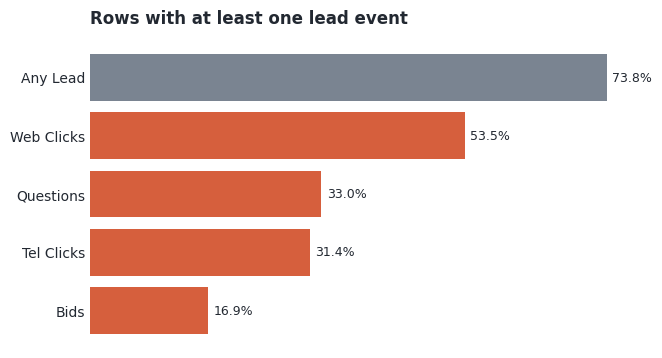

In [3]:
channel_mix = helpers.lead_channel_mix(insight_data)

display(helpers.style_table(channel_mix))
helpers.plot_lead_channel_coverage(insight_data)
helpers.plt.show()


### 1.2 Lead Activity Is Skewed

- 74% of ads receive at least one lead.
- The median ad receives only 2 total leads.
- The top decile of ads captures about 49% of all lead events.


,Metric,Value
0,Ads With At Least One Lead,0.738
1,Median Total Leads,2
2,P90 Total Leads,14
3,P99 Total Leads,40
4,Lead Events From Top-Decile Ads,0.487


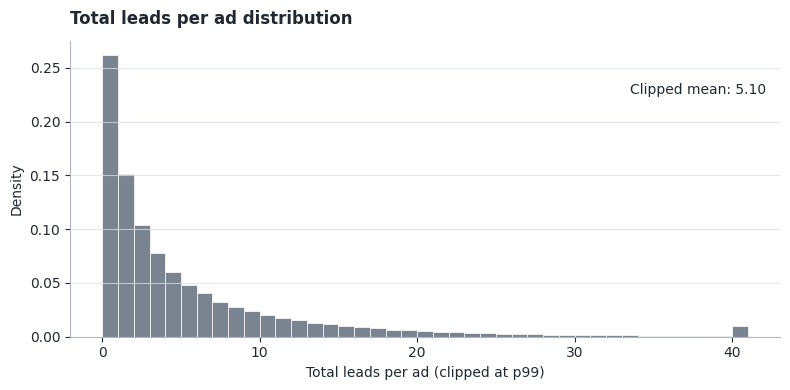

In [4]:
display(helpers.style_table(helpers.lead_concentration_summary(insight_data)))
helpers.plot_total_leads_distribution(insight_data)
helpers.plt.show()


## 2. Use Cases


### 2.1 Vehicle Segment Benchmarks

- Goal: identify listings that underperform similar vehicles and recommend the right seller action.
- Why it matters: marketplace averages can make healthy listings look weak, or weak listings look normal, if segment differences are ignored.
- Required join: seller/account data to turn listing-level benchmarks into seller actions.
- Helpful joins: final sale outcome to validate business impact, and listing edit history to measure whether seller changes improve performance.


#### Vehicle Demand Patterns

- Lower-price, older, and higher-mileage cars show higher lead rates in this dataset.
- These segment patterns make seller recommendations more defensible.
- Practical use: flag listings that underperform similar cars, then suggest a price check, content refresh, or promotion.
- Note: these are descriptive benchmarks; each band can still be affected by the mix of price, age, mileage, body type, and brand.
- A controlled analysis such as linear regression could help separate these effects, but that is out of scope for this project.


In [5]:
for segment_column in ["price_band", "km_band", "car_age_band"]:
    segment_summary = helpers.segment_benchmark_summary(insight_data, segment_column)
    display(helpers.style_segment_insight_table(segment_summary))


,Price Band,Ads,Lead Rate,Avg Leads/Ad,Median Car Age,Median Mileage,Ad Share
0,0-25k,"52,340",88.5%,8.689,15,"197,588",28.6%
1,25k-60k,"42,250",79.9%,5.815,10,"162,664",23.1%
2,60k-120k,"43,290",66.4%,3.524,6,"113,698",23.6%
3,120k+,"45,175",58.0%,2.694,3,"62,129",24.7%


,Mileage Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Car Age,Ad Share
3,200k+,"45,272",86.0%,7.167,"€22,500",13,24.7%
2,150k-200k,"35,863",82.5%,6.583,"€39,450",11,19.6%
1,75k-150k,"56,374",74.8%,5.117,"€69,500",7,30.8%
0,0-75k,"44,149",52.4%,2.525,"€139,000",2,24.1%


,Car Age Band,Ads,Lead Rate,Avg Leads/Ad,Median Price,Median Mileage,Ad Share
3,13+,"50,442",87.7%,8.113,"€14,500","198,456",27.6%
2,8-12,"52,457",81.5%,6.184,"€44,950","166,580",28.7%
1,4-7,"45,914",69.5%,3.941,"€97,500","108,701",25.1%
0,0-3,"34,249",47.0%,1.757,"€169,950","30,212",18.7%


In [6]:
body_type_summary = helpers.segment_insight_summary(insight_data, "carrosserie", min_ads=1000).head(10).drop(columns=["median_photos"])
brand_summary = helpers.segment_insight_summary(insight_data, "brand", min_ads=1000).head(10).drop(columns=["median_photos"])

display(helpers.style_segment_insight_table(body_type_summary))
display(helpers.style_segment_insight_table(brand_summary))


,Body Type,Ads,Lead Rate,Avg Leads/Ad,Median Price,Ad Share
1,Coup,"2,913",86.3%,7.863,"€89,500",1.6%
5,Sedan (2/4-deurs),"15,472",84.1%,7.035,"€59,500",8.5%
4,Overige carrosserie n,"2,494",76.9%,5.712,"€34,250",1.4%
0,Cabriolet,"5,290",75.9%,4.677,"€69,900",2.9%
6,Stationwagon,"29,233",74.2%,4.709,"€69,500",16.0%
7,Terreinwagen,"10,128",72.9%,4.649,"€169,400",5.5%
2,Hatchback (3/5-deurs),"79,944",71.9%,5.614,"€49,500",43.7%
3,MPV,"19,737",69.2%,3.879,"€49,990",10.8%


,Brand,Ads,Lead Rate,Avg Leads/Ad,Median Price,Ad Share
12,AUDI,"7,062",84.5%,6.658,"€122,475",3.9%
37,DAEWOO,"1,070",82.9%,7.456,"€9,995",0.6%
40,DAIHATSU,"1,052",82.5%,6.743,"€19,500",0.6%
3,ALFA ROMEO,"1,577",82.4%,6.674,"€44,950",0.9%
187,VOLKSWAGEN,"22,148",80.3%,6.862,"€69,000",12.1%
20,BMW,"9,259",80.1%,6.919,"€119,900",5.1%
123,MERCEDES,"7,809",79.6%,6.481,"€124,500",4.3%
165,SEAT,"4,906",79.4%,5.771,"€47,125",2.7%
120,MAZDA,"2,398",78.4%,5.169,"€33,675",1.3%
31,CHEVROLET,"1,513",76.7%,5.743,"€38,500",0.8%


### 2.2 Listing Quality Optimization

- Goal: help sellers improve listing content that may be limiting buyer interest.
- Why it matters: listing advice should focus on fields sellers can actually change.
- Required join: seller/account data to connect recommendations to actual sellers.
- Helpful joins: final sale outcome to check whether better content helps sales, and listing edit history to measure whether content changes improve lead performance.


#### Photo Count Signals

- Photo count alone is not a simple quality score.
- High-photo listings tend to be more expensive, which also affects lead rate.
- Use photo count as a benchmark within similar vehicle and price segments.


,Photo Count Band,Ads,Lead Rate,Avg Leads/Ad,Median Days Live,Median Price,Ad Share
0,0-5,"8,630",79.7%,8.092,31.000,"€18,500",4.7%
1,6-12,"61,208",81.6%,6.968,31.000,"€29,000",33.4%
2,13-20,"57,750",73.0%,4.934,31.000,"€59,950",31.5%
3,21+,"55,474",65.0%,3.488,31.000,"€117,450",30.3%


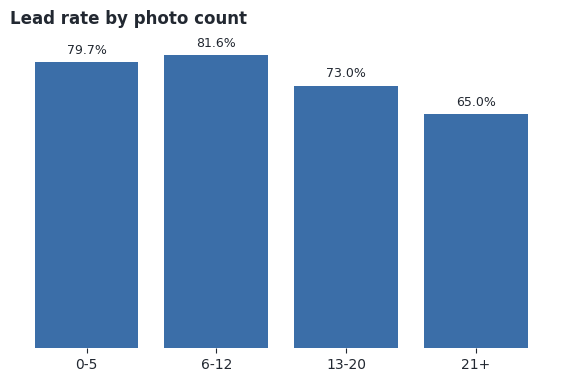

In [7]:
listing_quality = helpers.listing_quality_summary(insight_data)

display(helpers.style_table(listing_quality))
helpers.plot_photo_count_lead_rate(listing_quality)
helpers.plt.show()


- Practical use: flag listings with unusually weak content compared with similar cars.
- Avoid a simplistic rule like "more photos always means more leads".


### 2.3 Listing Lifecycle Nudges

- Goal: nudge sellers at the right moment, before a listing becomes stale.
- Why it matters: listing age changes how we should read lead performance.
- Required join: seller/account data to deliver nudges to the right sellers.
- Helpful joins: listing edit history to detect seller changes, paid exposure history to separate organic from promoted performance, and final sale outcome to validate business impact.


#### Listing Lifecycle Signals

- Check early if new listings are getting leads.
- Mid-life listings can be compared against segment benchmarks.
- Stale listings with weak lead performance may need a refresh, price check, or promotion.
- These lifecycle patterns are descriptive, not causal. I would use them as triggers for diagnosis, not as proof that listing age drives lead performance.


,Days Live Band,Ads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Median Price,Median Photos,Ad Share
0,0-3,"14,771",71.3%,5.486,3.000,"€29,990",12.000,8.1%
1,4-7,"14,766",79.8%,7.916,4.000,"€36,500",14.000,8.1%
2,8-14,"16,583",81.7%,7.199,4.000,"€39,990",15.000,9.1%
3,15-31,"127,195",70.9%,4.483,2.000,"€69,500",16.000,69.5%
4,31+,"9,747",92.8%,8.951,6.000,"€37,500",11.000,5.3%


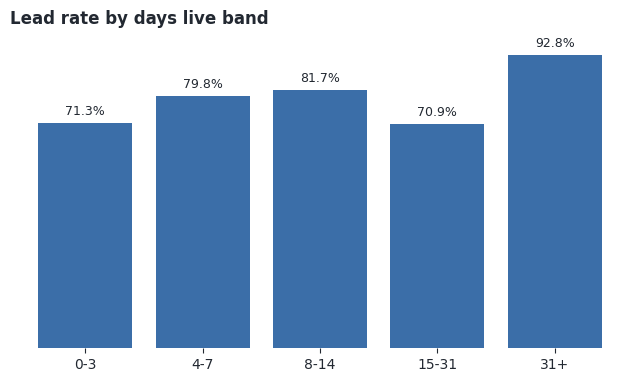

In [8]:
lifecycle_summary = helpers.lifecycle_summary(insight_data)

display(helpers.style_table(lifecycle_summary))
helpers.plot_lifecycle_lead_rate(lifecycle_summary)
helpers.plt.show()


In [9]:
fresh_stale_summary = helpers.fresh_stale_summary(insight_data)

display(helpers.style_table(fresh_stale_summary))


,Lifecycle Stage,Ads,Lead Rate,Avg Leads/Ad,Median Leads/Ad,Median Price,Median Photos,Median Mileage,Ad Share
0,Fresh: 0-7 days,"29,537",75.5%,6.701,3.000,"€33,500",13.000,"155,151",16.1%
1,Mid-life: 8-31 days,"143,778",72.1%,4.796,2.000,"€66,900",16.000,"132,728",78.5%
2,Stale: 31+ days,"9,747",92.8%,8.951,6.000,"€37,500",11.000,"169,400",5.3%


- Practical use: trigger different recommendations based on listing age and lead performance.
- Example: a stale listing with low leads can receive a refresh or promotion suggestion.
